# This script generates a video of general hive visualisation

## Imports

In [1]:
import multiprocessing, cv2, os, sys
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
sys.path.append(os.path.abspath('RHCThermalPlots'))
sys.path.append(os.path.abspath('RHCImaging'))
from libvisu import *
from RHCImaging.libimage import fetchImagesPaths
from RHCImaging.VideoManagment.videolib import initVideoWriter
from RHCThermalPlots.thermalutil import generateThermalDF
from RHCThermalPlots.thermalframe import NoValidSensors
from InfluxDBInterface.libdb import download_data_DB, removeTmpOutliers
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a wide width for display
pd.set_option('display.colheader_justify', 'center')  # Align column headers
from dask.distributed import Client
# Start a client using all CPUs of this machine
client = Client()
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-iwxv0kfe', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-pr4ivjza', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-ipn6k5h0', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-dojn_h15', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/scheduler-6chtnxti', purging
INFO:distributed.

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52201,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52213,Total threads: 3
Dashboard: http://127.0.0.1:52217/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:52204,


## Configuration

In [ ]:
# ==== GENERAL SETTINGS ====
download_data = True    # Set to True to download data from InfluxDB, False to use data stored locally
hive_nb = 1             # Hive number to process (1 or 2 for OH, 3 for BH and 0 for debugging)
ihl = None              # IHL to consider for sensory data (Put None to consider both IHLs)
t_res = "1min"          # Image time resolution. Change only if images are not taken every minute. Use frame_drop to keep only some frames, not this.
rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11_aSensing_OH/Images/'     # For images
first_dt = pd.Timestamp('2024-11-12 06:00:00').tz_localize('UTC') # Idle exp
last_dt = pd.Timestamp('2024-11-22 16:00:00').tz_localize('UTC')
frame_drop = 20         # We keep 1 frame every frame_drop frames. Put one to keep all frames.
images_fill_limit = 10  # Maximum number of consecutive missing images to fill with the last available image. Put None to disable filling.
fps = 15                # FPS of the output video

thermal_shift = 'aSensing1' # The thermal shift to apply. Use None for no shift
show_co2 = True        # Set to True to show CO2 data on the video
show_htrs = True       # Set to True to show heater data on the video

dest = "outputVideos/metabolism/"

verbose = False          # Set to True to print progress and debug messages

# ==== LOCAL DATA CONFIGURATION ====
if not download_data:
    data_path = 'data/2025-10-06_13-18_influxdb_data.csv' # Path to the local .csv or .dat file containing the CO2, htr and tmp data

# ==== DATA DOWNLOAD CONFIGURATION ====
if download_data:
    bucket = 'a_sensing' # InfluxDB bucket to download data from

## Main code

### Image fetching

In [3]:
# Get the target dt (for which we need an image, data, etc.)
datetimes = pd.date_range(start=first_dt, end=last_dt, freq=t_res)
datetimes = datetimes[::frame_drop]

# Print the number of dts considered
print(f"Number of datetimes considered: {len(datetimes)}")

imgs_paths = fetchImagesPaths(rootpath_imgs, datetimes, hive_nb, images_fill_limit=images_fill_limit, verbose=verbose)
print(imgs_paths)
# Count the number of Nones across all rows and all columns
none_count = imgs_paths.isnull().sum().sum()
print(f"Number of missing images: {none_count} out of {len(imgs_paths) * imgs_paths.shape[1]} total images.")

Number of datetimes considered: 676


Fetching image paths: 100%|██████████| 676/676 [00:01<00:00, 647.10it/s]

Missing images before filtering: 0 out of 2704
                                                 h2r1                                               h2r2                                               h2r3                                               h2r4                       
2024-11-09 23:00:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-11-09 23:20:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-11-09 23:40:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-11-10 00:00:00+00:00  /Users

### Htr, co2 and tmp data fetching

In [4]:
if download_data:
    data_res = int(t_res[0]) * 60 * frame_drop
    filters = {'hive_num': str(hive_nb),
               'measurement': ['tmp']}
    if show_co2:
        filters['measurement'].append('co2')  # Add CO2 sensor data if needed
    if show_htrs:
        filters['measurement'].append('htr')  # Add heater data if needed
    if ihl in ['upper', 'lower']:
        filters['inhive_loc'] = ihl

    # We take a higher frequency than needed to perform filtering
    hive_data = download_data_DB(bucket, first_dt, last_dt, data_res, filters, verbose=verbose) # Restricted to our time frame and hive
    
else:
    data_path = os.path.abspath(data_path)          # Absolute path to the data
    hive_data = extractData(data_path, hive_nb, datetimes, verbose=False) # Restricted to our time frame and hive
print(hive_data.head())
# Print out the number of unique index entries (datetimes)
print(f"Number of unique datetimes in the data: {hive_data.index.nunique()}")

                                    _start                    _stop             _value    _field  _measurement board_id geo_loc hive_num inhive_loc          mcu_uuid          phys_loc  rpi_num   serial_id    valid DeltaT actuator_instance content  filling_density
_time                                                                                                                                                                                                                                                                  
2024-11-09 23:00:00+00:00 2024-11-09 22:40:00+00:00 2024-11-19 08:00:00+00:00   0.00000    status      htr       abc03    EPFL      2       lower    2191217016663093217343026   bass       2     /dev/ttyACM0  True    0.0          h01        Unknown      Unknown   
2024-11-09 23:00:00+00:00 2024-11-09 22:40:00+00:00 2024-11-19 08:00:00+00:00   0.00000    status      htr       abc03    EPFL      2       lower    2191217016663093217343026   bass       2     /dev/ttyACM0  

### tmp fetching

In [5]:
upper, lower = generateThermalDF(hive_data)   # Only tmp data, in a format that can be used by ThermalFrame

# Cleaning step of all tmp data: remove outliers
for i, df in enumerate([upper, lower]):
    for col in df.columns:
        df[col] = removeTmpOutliers(df[col], allowed_variation=2.0)

# Restrain both dataframes to the target datetimes
upper = upper[upper.index.isin(datetimes)]
lower = lower[lower.index.isin(datetimes)]
print("After restraining to target datetimes:")
print("Upper hive data shape: ", upper.shape)
print("Lower hive data shape: ", lower.shape)

# Seek the max and min values of the tmp data, in both upper and lower hives
if upper.empty:
    max_temp = np.nanmax(lower.to_numpy())
    min_temp = np.nanmin(lower.to_numpy())
elif lower.empty:
    max_temp = np.nanmax(upper.to_numpy())
    min_temp = np.nanmin(upper.to_numpy())
else:
    max_temp = np.nanmax([upper.to_numpy(), lower.to_numpy()])
    min_temp = np.nanmin([upper.to_numpy(), lower.to_numpy()])

print("Max temperature in the selected time range: ", max_temp)
print("Min temperature in the selected time range: ", min_temp)
print(lower)

After restraining to target datetimes:
Upper hive data shape:  (676, 64)
Lower hive data shape:  (676, 64)
Max temperature in the selected time range:  36.3671875
Min temperature in the selected time range:  7.3828125
                              t00        t01        t02        t03        t04        t05        t06        t07        t08        t09        t10        t11        t12        t13        t14        t15        t16        t17        t18        t19        t20        t21        t22        t23        t24        t25        t26        t27        t28        t29        t30        t31        t32        t33        t34        t35        t36        t37        t38        t39        t40        t41        t42        t43        t44        t45        t46        t47        t48        t49        t50        t51        t52        t53        t54        t55        t56        t57        t58        t59        t60        t61        t62        t63   
_time                                               

### Metabolic data fetching

In [6]:
if show_co2:
    # Now we fetch the metabolic data
    co2_data =generateMetabolicDF(hive_data)
    # Restrain co2_data to the target datetimes
    co2_data = co2_data[co2_data.index.isin(datetimes)]
    print(co2_data)
else:
    co2_data = pd.DataFrame()  # Empty DataFrame if CO2 data is not to be shown

                              ul        ur        ll       lr  
_time                                                          
2024-11-09 23:00:00+00:00   2943.598   1633.0  2084.641   386.0
2024-11-09 23:20:00+00:00   2830.245   1035.0  2195.604   305.0
2024-11-09 23:40:00+00:00   3480.844   1429.0  2044.533   299.0
2024-11-10 00:00:00+00:00   4752.180   1111.0  2640.541   240.0
2024-11-10 00:20:00+00:00   2918.928   1737.0  1566.971   296.0
...                              ...      ...       ...     ...
2024-11-19 06:40:00+00:00   8104.529  17802.0  4597.812  8146.0
2024-11-19 07:00:00+00:00  15003.820  16573.0  6990.723  1390.0
2024-11-19 07:20:00+00:00   8370.027  14344.0  5563.625  8983.0
2024-11-19 07:40:00+00:00   8360.789  16316.0  2678.679  5587.0
2024-11-19 08:00:00+00:00   9658.626   5704.0  3333.389  2911.0

[676 rows x 4 columns]


### htr fetching

In [7]:
if show_htrs:
    upper_htr = (
        hive_data
        .loc[(hive_data["inhive_loc"] == "upper") & (hive_data["_measurement"] == "htr")]
        .drop(columns=["_measurement", "_start", "_stop"])
        .copy()
    )

    lower_htr = (
        hive_data
        .loc[(hive_data["inhive_loc"] == "lower") & (hive_data["_measurement"] == "htr")]
        .drop(columns=["_measurement", "_start", "_stop"])
        .copy()
    )

    # Restrain both dataframes to the target datetimes
    upper_htr = upper_htr[upper_htr.index.isin(datetimes)]
    lower_htr = lower_htr[lower_htr.index.isin(datetimes)]
    print(upper_htr)
    print(lower_htr)
else:
    upper_htr = pd.DataFrame()  # Empty DataFrame if htr data is not to be shown
    lower_htr = pd.DataFrame()  # Empty DataFrame if htr data is not to be shown

                            _value    _field  board_id geo_loc hive_num inhive_loc          mcu_uuid          phys_loc  rpi_num   serial_id    valid DeltaT actuator_instance content  filling_density
_time                                                                                                                                                                                                 
2024-11-09 23:00:00+00:00   0.00000       obj   abc02    EPFL      2       upper    2191218169584597824190002   bass       1     /dev/ttyACM0  True    0.0          h08        Unknown      Unknown   
2024-11-09 23:00:00+00:00  15.64844  avg_temp   abc02    EPFL      2       upper    2191218169584597824190002   bass       1     /dev/ttyACM0  True    0.0          h01        Unknown      Unknown   
2024-11-09 23:00:00+00:00   0.00000       obj   abc02    EPFL      2       upper    2191218169584597824190002   bass       1     /dev/ttyACM0  True    0.0          h00        Unknown      Unknown   
2024-

### Frame generation

In [8]:
def generate_frame(dt:pd.Timestamp, contours:list = []):
    """Generate a single annotated frame for the given datetime.

    Args:
        dt (pd.Timestamp): The datetime for which to generate the frame.
    Returns:
        np.ndarray: The generated annotated frame as an image array.
    """

    # Fetch the corresponding image paths
    _imgs_paths = imgs_paths.loc[dt].to_numpy()
    imgs_names = [str(_imgs_paths[j]).split("/")[-1][:-4] for j in range(len(_imgs_paths))]
    # Read the images using cv2
    current_imgs = []
    for _img_path in _imgs_paths:
        if _img_path is not None:
            img = cv2.imread(_img_path, cv2.IMREAD_GRAYSCALE)
            current_imgs.append(img)
        else:
            current_imgs.append(None)
    
    # Thermal data
    try:
        upper_tf = ThermalFrame(upper.loc[dt].to_numpy())
    except (NoValidSensors, KeyError):
        upper_tf = None

    try:
        lower_tf = ThermalFrame(lower.loc[dt].to_numpy())
    except (NoValidSensors, KeyError):
        lower_tf = None

    # Metabolic data
    if dt in co2_data.index:
        metabolic_df = co2_data.loc[dt]
    else:
        metabolic_df = None

    # Lower heater
    if dt in lower_htr.index:
        lower_htr_row = lower_htr.loc[dt]
    else:
        lower_htr_row = None

    # Upper heater
    if dt in upper_htr.index:
        upper_htr_row = upper_htr.loc[dt]
    else:
        upper_htr_row = None
    
    hs = Hive(dt, current_imgs, False, imgs_names, upper_tf, lower_tf, metabolic_df, upper_htr_row, lower_htr_row, hive_nb=hive_nb)
    if thermal_shift is not None:
        from libvisu import exp_thermal_shifts
        hs.setThermalShifts(exp_thermal_shifts[thermal_shift][hive_nb])
    snapshot = hs.snapshot(v_max=max_temp, v_min=min_temp, contours=contours, annotate_contours=True, thermal_transparency=0.4, check_validity=True, annotate_names=False, use_cet_time=False)

    return snapshot

### Plotting

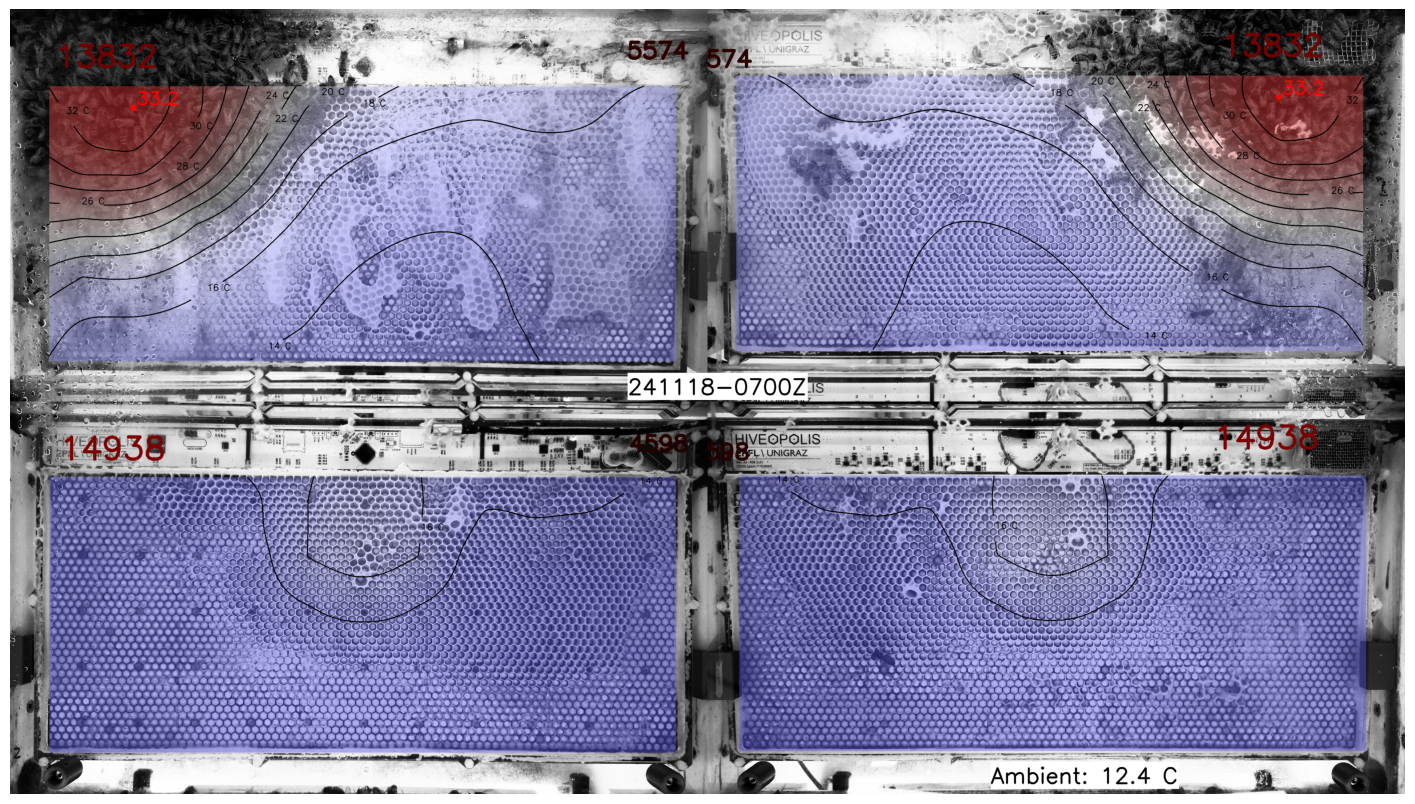

In [9]:
frame = 600 # Frame idx within datetimes
dt = datetimes[frame]
_imgs_paths = imgs_paths.loc[dt].to_numpy()
contours = list(range(12, 38, 2))
snapshot = generate_frame(dt, contours=contours)
# For a random time frame, generate the image of the hive and the thermal plot side by side with matplotlib
# This is just to check that everything is working fine
plt.figure(figsize=(18, 12))
plt.imshow(snapshot)
plt.axis('off') 
plt.show()

### Automation

In [10]:
snapshot_0 = generate_frame(datetimes[0], contours=contours)
filename=f"hive{hive_nb}_{first_dt.strftime('%y%m%d-%H%M%Z')}_{last_dt.strftime('%y%m%d-%H%M%Z')}"
# If file exists, add a number to the name
counter = 1
while os.path.isfile(dest+filename+".mp4"):
    print(f"File {filename} already exists. Adding a counter to the filename.")
    if counter > 1:
        # Remove the previous counter
        filename = filename[:-(len(str(counter-1))+1)]
    filename = f"{filename}_{counter}"
    counter += 1
    
video = initVideoWriter(dest=dest, shape=snapshot_0.shape, name=filename, fps=fps) # RGB video
print("Writing video with dimensions: ", snapshot_0.shape)

for dt in tqdm(datetimes, desc="Generating video frames"):
    snapshot = generate_frame(dt, contours=contours)
    # Convert from RGB to BGR
    snapshot = cv2.cvtColor(snapshot, cv2.COLOR_RGB2BGR)
    video.write(snapshot)

# Release the VideoWriter object
video.release()
print("Video written successfully.")

# Cleanup step to release resources
multiprocessing.active_children()

Writing video with dimensions:  (2160, 3840, 3)


Generating video frames: 100%|██████████| 676/676 [13:31<00:00,  1.20s/it]

Video written successfully.


[<SpawnProcess name='Dask Worker process (from Nanny)' pid=8052 parent=8026 started daemon>,
 <SpawnProcess name='Dask Worker process (from Nanny)' pid=8054 parent=8026 started daemon>,
 <SpawnProcess name='Dask Worker process (from Nanny)' pid=8055 parent=8026 started daemon>,
 <SpawnProcess name='Dask Worker process (from Nanny)' pid=8053 parent=8026 started daemon>]